In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# =============================================================================
## 1. Configuration and Hyperparameters
# =============================================================================
DATA_DIR = "/kaggle/input/mepco-tropic-leaf/MepcoTropicLeaf-V1/Database"
NUM_CLASSES = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 50 # We can set this higher, early stopping will handle it
EARLY_STOPPING_PATIENCE = 5 # Number of epochs to wait for improvement

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("-" * 20)

Using device: cuda:0
--------------------


In [3]:
# =============================================================================
## 2. Data Transformations
# =============================================================================
# Define separate transforms for training (with augmentation) and validation/testing (no augmentation)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [4]:
# =============================================================================
## 3. Dataset Splitting, Loading, and Class Weighting
# =============================================================================
class CustomSubset(Dataset):
    # ... (Identical to the previous script)
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        path, target = self.subset.dataset.samples[self.subset.indices[index]]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, target
    def __len__(self):
        return len(self.subset.indices)

full_dataset = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
print(f"Found {len(class_names)} classes.")

# --- NEW: Calculate Class Weights for Imbalanced Data ---
print("Calculating class weights...")
class_counts = np.bincount([s[1] for s in full_dataset.samples])
total_samples = len(full_dataset.samples)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights calculated.")
# ---------------------------------------------------------

dataset_size = len(full_dataset)
train_size = int(0.70 * dataset_size)
val_size = int(0.20 * dataset_size)
test_size = dataset_size - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = CustomSubset(train_subset, transform=data_transforms['train'])
val_dataset = CustomSubset(val_subset, transform=data_transforms['val'])
test_dataset = CustomSubset(test_subset, transform=data_transforms['val'])

# Print dataset sizes
print(f"Total images:        {dataset_size}")
print(f"Training set size:   {len(train_dataset)} ({len(train_dataset) / dataset_size:.0%})")
print(f"Validation set size: {len(val_dataset)} ({len(val_dataset) / dataset_size:.0%})")
print(f"Test set size:       {len(test_dataset)} ({len(test_dataset) / dataset_size:.0%})")
print("-" * 20)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4),
    'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
}



Found 50 classes.
Calculating class weights...
Class weights calculated.
Total images:        3777
Training set size:   2643 (70%)
Validation set size: 755 (20%)
Test set size:       379 (10%)
--------------------


In [5]:

# =============================================================================
## 4. Model Setup
# =============================================================================
model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)

# --- MODIFIED: Use the calculated class weights in the loss function ---
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# ----------------------------------------------------------------------
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1, verbose=True)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 271MB/s]


In [6]:
# =============================================================================
## 5. NEW: Early Stopping Class
# =============================================================================
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [7]:
# =============================================================================
## 5. Training and Validation Loop
# =============================================================================
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, verbose=True)

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}'); print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase.capitalize()} Phase"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step(epoch_loss)

            if phase == 'val':
                # --- Early stopping check ---
                early_stopping(epoch_loss, model)
                if early_stopping.early_stop:
                    print("Early stopping triggered")
                    # Load the best model weights before returning
                    model.load_state_dict(torch.load('checkpoint.pt'))
                    return model, history
        print()

    # Load the best model weights in case training finishes without early stopping
    model.load_state_dict(torch.load('checkpoint.pt'))
    return model, history


In [8]:
## 7. MODIFIED: Testing Function with Comprehensive Metrics

def test_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("\nEvaluating on the test set for comprehensive metrics...")
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- Classification Report ---
    print("\n--- Classification Report ---")

    # This is the only line you need to change:
    # We add `labels=...` to tell sklearn about all 30 possible classes.
    print(classification_report(
        all_labels, 
        all_preds, 
        labels=list(range(len(class_names))), # Explicitly list all class indices [0, 1, ..., 29]
        target_names=class_names,
        zero_division=0 # Set metrics to 0 for classes with no samples
    ))
    
    # --- Confusion Matrix ---
    print("\n--- Confusion Matrix ---")
    # For the confusion matrix, it's also good practice to specify the labels
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

In [9]:
# =============================================================================
## 8. Main Execution Block
# =============================================================================
if __name__ == "__main__":
    trained_model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)

Epoch 1/50
----------


Train Phase: 100%|██████████| 83/83 [00:23<00:00,  3.48it/s]


train Loss: 3.5000 Acc: 0.1438


Val Phase: 100%|██████████| 24/24 [00:06<00:00,  3.85it/s]


val Loss: 2.5707 Acc: 0.5007
Validation loss decreased (inf --> 2.570719). Saving model ...

Epoch 2/50
----------


...

val Loss: 0.1992 Acc: 0.9351
Epoch 00032: reducing learning rate of group 0 to 1.0000e-05.
EarlyStopping counter: 4 out of 5

Epoch 33/50
----------


Train Phase: 100%|██████████| 83/83 [00:20<00:00,  3.98it/s]


train Loss: 0.2959 Acc: 0.9001


Val Phase: 100%|██████████| 24/24 [00:05<00:00,  4.23it/s]


val Loss: 0.1928 Acc: 0.9325
EarlyStopping counter: 5 out of 5
Early stopping triggered



Evaluating on the test set for comprehensive metrics...


Testing: 100%|██████████| 12/12 [00:03<00:00,  3.47it/s]



--- Classification Report ---
                                 precision    recall  f1-score   support

               Asthma Plant.zip       0.00      0.00      0.00         0
                     Avaram.zip       0.91      1.00      0.95        10
               Balloon vine.zip       1.00      0.79      0.88        19
     Bellyache bush (Green).zip       1.00      1.00      1.00        11
          Benghal dayflower.zip       0.60      1.00      0.75         3
               Big Caltrops.zip       1.00      0.50      0.67         6
          Black-Honey Shrub.zip       1.00      0.86      0.92         7
         Bristly Wild Grape.zip       1.00      1.00      1.00         5
              Butterfly Pea.zip       1.00      1.00      1.00         7
            Cape Gooseberry.zip       0.77      0.91      0.83        11
            Common Wireweed.zip       1.00      1.00      1.00         7
             Country Mallow.zip       1.00      1.00      1.00         9
               Crow

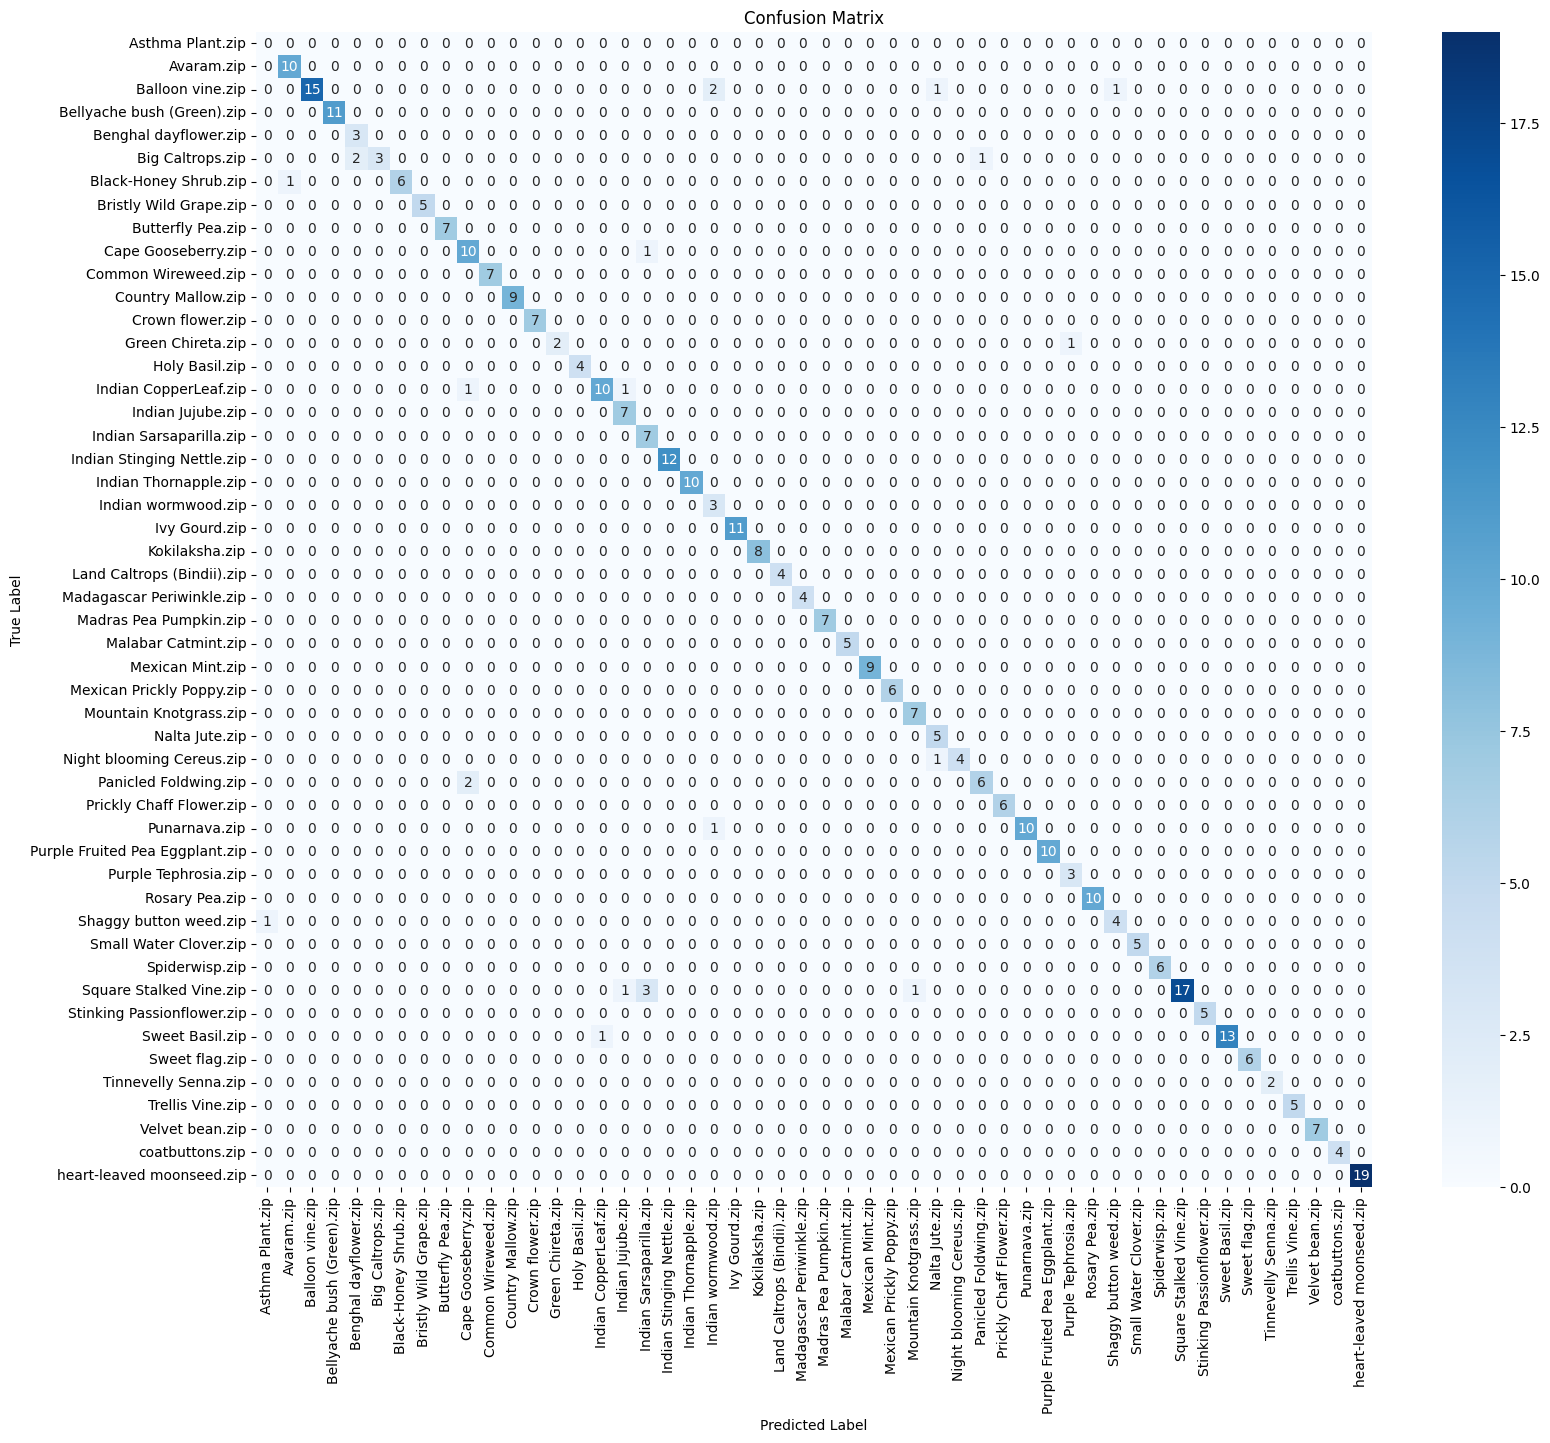

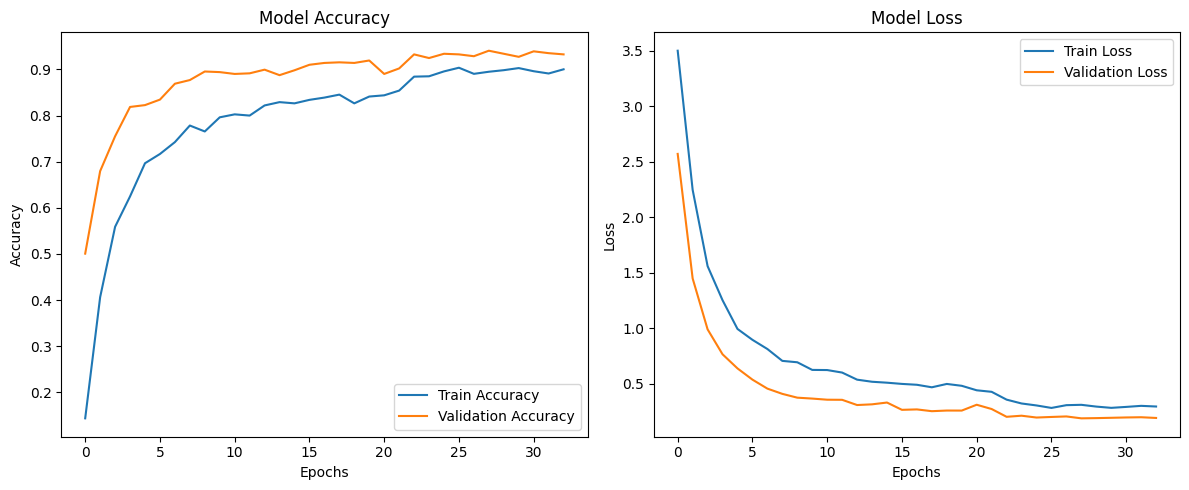

In [10]:
# The best model is already loaded by the train_model function
test_model(trained_model, dataloaders['test'], class_names)

# Plotting the training and validation history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
test_loader = dataloaders['test']
model = trained_model
model.eval()
running_corrects = 0

print("\nEvaluating on the test set...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        running_corrects += torch.sum(preds == labels.data)
        
test_acc = running_corrects.double() / len(test_loader.dataset)
print(f'\nTest Accuracy: {test_acc:.4f}')


Evaluating on the test set...


Testing: 100%|██████████| 12/12 [00:03<00:00,  4.00it/s]


Test Accuracy: 0.9393


In [12]:
# Save the final best model
torch.save(trained_model.state_dict(), 'medicinal_leaf_classifier_best.pth')
print("\nBest model saved to 'medicinal_leaf_classifier_best.pth'")


Best model saved to 'medicinal_leaf_classifier_best.pth'
